In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/blood-cells")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/blood-cells


In [3]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 10.7 MB/s eta 0:00:0000:010:01


In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import skfuzzy as fuzz

In [9]:
# Correct path based on your dataset structure
image_folder = "/kaggle/input/blood-cells/dataset-master/dataset-master/JPEGImages"

# Verify dataset
files = os.listdir(image_folder)

print("Total images available:", len(files))

# Use only first 30 images for faster execution
files = files[:30]

print("Images selected for processing:", len(files))

Total images available: 366
Images selected for processing: 30


In [10]:
def dice_score(gt, pred):

    intersection = np.sum(gt * pred)

    return (2.0 * intersection) / (np.sum(gt) + np.sum(pred) + 1e-7)



def jaccard_index(gt, pred):

    intersection = np.sum(gt * pred)

    union = np.sum(gt) + np.sum(pred) - intersection

    return intersection / (union + 1e-7)

In [11]:
def create_ground_truth(image):

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    gray = cv2.resize(gray, (128,128))   # smaller size = faster

    _, gt = cv2.threshold(
        gray,
        0,
        1,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    return gt

In [12]:
def segment_kmeans(image, k=3):

    image = cv2.resize(image, (128,128))

    pixels = image.reshape((-1,3))
    pixels = np.float32(pixels)

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = kmeans.fit_predict(pixels)

    segmented = labels.reshape(image.shape[:2])

    centers = kmeans.cluster_centers_

    intensity = np.mean(centers, axis=1)

    nucleus_cluster = np.argmin(intensity)

    nucleus = (segmented == nucleus_cluster).astype(np.uint8)

    return nucleus

In [13]:
def segment_fcm(image, k=3):

    image = cv2.resize(image, (128,128))

    pixels = image.reshape((-1,3))
    pixels = np.float32(pixels)

    data = pixels.T

    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        data,
        c=k,
        m=2,
        error=0.005,
        maxiter=300   # reduced for speed
    )

    labels = np.argmax(u, axis=0)

    segmented = labels.reshape(image.shape[:2])

    intensity = np.mean(cntr, axis=1)

    nucleus_cluster = np.argmin(intensity)

    nucleus = (segmented == nucleus_cluster).astype(np.uint8)

    return nucleus

Processing images...

Processed 1/30


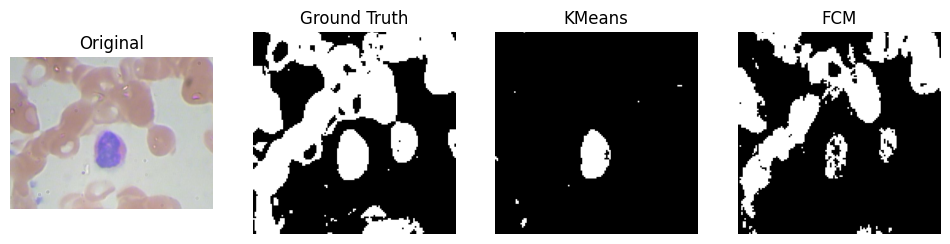

Processed 2/30


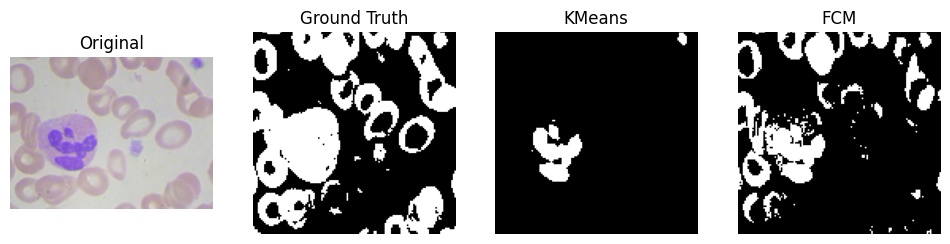

Processed 3/30


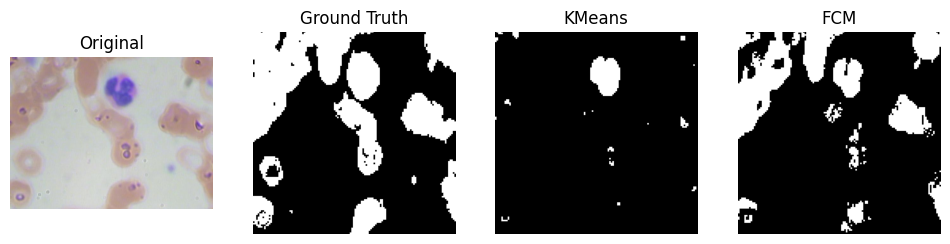

Processed 4/30
Processed 5/30
Processed 6/30
Processed 7/30
Processed 8/30
Processed 9/30
Processed 10/30
Processed 11/30
Processed 12/30
Processed 13/30
Processed 14/30
Processed 15/30
Processed 16/30
Processed 17/30
Processed 18/30
Processed 19/30
Processed 20/30
Processed 21/30
Processed 22/30
Processed 23/30
Processed 24/30
Processed 25/30
Processed 26/30
Processed 27/30
Processed 28/30
Processed 29/30
Processed 30/30


In [14]:
dice_kmeans_list = []
dice_fcm_list = []

jaccard_kmeans_list = []
jaccard_fcm_list = []

image_count = 0

print("Processing images...\n")

for filename in files:

    image_path = os.path.join(image_folder, filename)

    image = cv2.imread(image_path)

    if image is None:
        continue

    gt = create_ground_truth(image)

    nucleus_kmeans = segment_kmeans(image)

    nucleus_fcm = segment_fcm(image)

    dice_kmeans_list.append(dice_score(gt, nucleus_kmeans))
    dice_fcm_list.append(dice_score(gt, nucleus_fcm))

    jaccard_kmeans_list.append(jaccard_index(gt, nucleus_kmeans))
    jaccard_fcm_list.append(jaccard_index(gt, nucleus_fcm))

    image_count += 1

    print(f"Processed {image_count}/30")

    # Show first 3 results
    if image_count <= 3:

        plt.figure(figsize=(12,4))

        plt.subplot(1,4,1)
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1,4,2)
        plt.imshow(gt, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1,4,3)
        plt.imshow(nucleus_kmeans, cmap="gray")
        plt.title("KMeans")
        plt.axis("off")

        plt.subplot(1,4,4)
        plt.imshow(nucleus_fcm, cmap="gray")
        plt.title("FCM")
        plt.axis("off")

        plt.show()

In [15]:
print("\n===================================")
print("FINAL RESULTS")
print("===================================")

print("Total images processed:", image_count)

print("\nAverage Dice Score:")
print("KMeans:", round(np.mean(dice_kmeans_list), 4))
print("FCM:", round(np.mean(dice_fcm_list), 4))

print("\nAverage Jaccard Score:")
print("KMeans:", round(np.mean(jaccard_kmeans_list), 4))
print("FCM:", round(np.mean(jaccard_fcm_list), 4))


FINAL RESULTS
Total images processed: 30

Average Dice Score:
KMeans: 0.2994
FCM: 0.6774

Average Jaccard Score:
KMeans: 0.2151
FCM: 0.5374
